In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os
import pdb
from tqdm import tqdm
import re

print('GOGOGO!')

GOGOGO!


In [12]:
# Get all available font families
font_families = matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf')

# Print the font families
print("Available Font Families:")
for font_path in font_families:
    try:
        font_property = matplotlib.font_manager.FontProperties(fname=font_path)
        font_family = font_property.get_name()
        print(font_family)
    except Exception as e:
        print(f"Error processing font file {font_path}: {e}")


Available Font Families:
Leelawadee UI
Microsoft Tai Le
Wingdings
Euclid Math One
YouYuan
Eras Light ITC
Comic Sans MS
Franklin Gothic Demi
Old English Text MT
Bodoni MT
Times New Roman
KaiTi
Colonna MT
Verdana
Lucida Sans Unicode
Microsoft Yi Baiti
Constantia
Tw Cen MT
Lucida Console
Goudy Stout
MS Outlook
Yu Gothic
Blackadder ITC
STFangsong
Gadugi
Agency FB
Ebrima
Ink Free
Microsoft YaHei
STCaiyun
Microsoft JhengHei
Segoe UI
Berlin Sans FB Demi
Tahoma
Gill Sans MT Condensed
Courier New
Gill Sans MT
Corbel
Informal Roman
Consolas
Century Schoolbook
Segoe MDL2 Assets
Edwardian Script ITC
Century Gothic
MingLiU-ExtB
Lucida Bright
Comic Sans MS
Modern No. 20
Segoe UI
Elephant
Segoe UI
Cambria
Verdana
Microsoft PhagsPa
STXihei
Brush Script MT
FZShuTi
Segoe Print
Microsoft JhengHei
Euclid
Magneto
Noto Serif SC
Euclid
Calibri
Californian FB
Rockwell Condensed
DengXian
Noto Sans SC
Microsoft New Tai Lue
Cambria
Lucida Sans Typewriter
Engravers MT
MT Extra Tiger
Viner Hand ITC
Candara
Consola

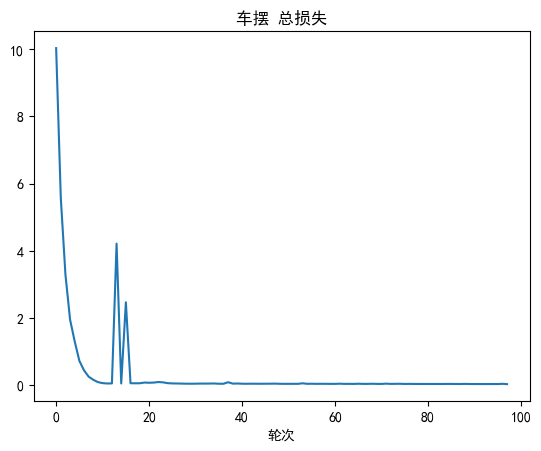

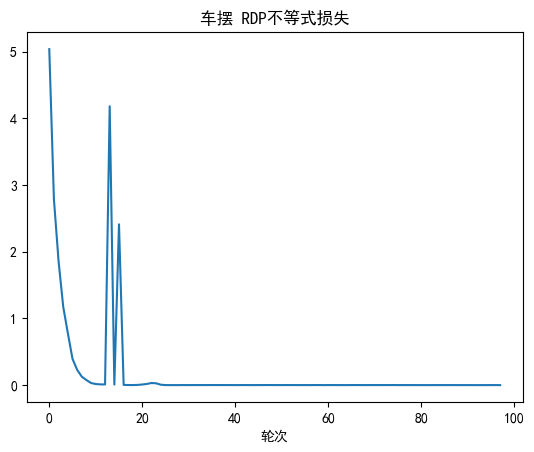

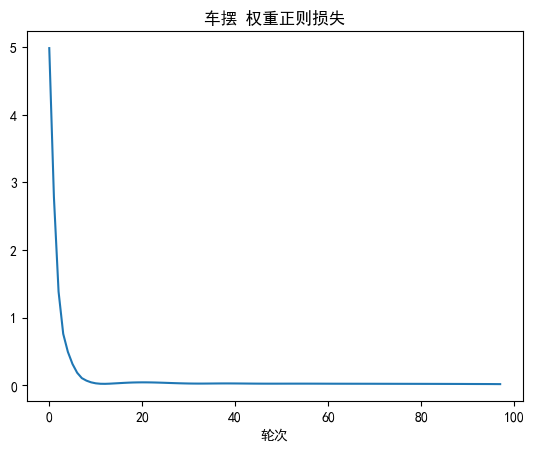

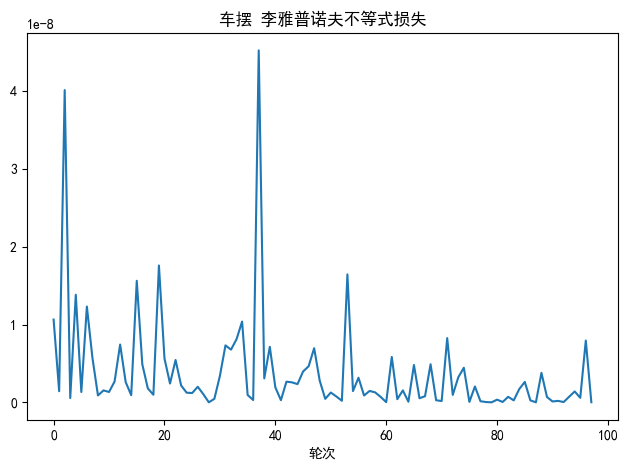

In [16]:
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus']=False  # 用来正常显示负号
def parse_log_file(log_file_path):
    """
    Parses a log file to extract training data (epoch, loss, rdp loss, weight penalty, lyap loss).

    Args:
        log_file_path (str): The path to the log file.

    Returns:
        dict: A dictionary containing lists of epoch numbers, loss values, rdp loss values,
              weight penalty values, and Lyapunov loss values.  Returns empty lists if no data is found.
    """

    epochs = []
    losses = []
    rdp_losses = []
    weight_penalties = []
    lyap_losses = []

    with open(log_file_path, 'r') as f:
        for line in f:
            # Use regular expressions to extract the data
            match = re.search(r"Epoch: (\d+), loss: ([\d\.]+).*?rdp loss: ([\d\.]+).*?weight penalty: ([\d\.]+).*?Lyap loss: tensor\(\[([\d\.e\-\+]+)\].*", line)
            if match:
                epoch = int(match.group(1))
                loss = float(match.group(2))
                rdp_loss = float(match.group(3))
                weight_penalty = float(match.group(4))
                lyap_loss = float(match.group(5))

                epochs.append(epoch)
                losses.append(loss)
                rdp_losses.append(rdp_loss)
                weight_penalties.append(weight_penalty)
                lyap_losses.append(lyap_loss)

    return {
        'epochs': epochs,
        'losses': losses,
        'rdp_losses': rdp_losses,
        'weight_penalties': weight_penalties,
        'lyap_losses': lyap_losses
    }


def plot_training_data(data, title_prefix="车摆"):
    """
    Plots the training data (loss, rdp loss, weight penalty, Lyapunov loss) against epoch.

    Args:
        data (dict): A dictionary containing lists of epoch numbers, loss values, rdp loss values,
                     weight penalty values, and Lyapunov loss values, as returned by parse_log_file.
        title_prefix (str, optional): Prefix for the plot titles. Defaults to "Training".
    """

    epochs = data['epochs']
    losses = data['losses']
    rdp_losses = data['rdp_losses']
    weight_penalties = data['weight_penalties']
    lyap_losses = data['lyap_losses']

    if not epochs:
        print("No data to plot.")
        return

    plt.figure()
    plt.plot(losses)
    plt.xlabel('轮次')
    plt.title(f'{title_prefix} 总损失')

    plt.figure()
    plt.plot(rdp_losses)
    plt.xlabel('轮次')
    plt.title(f'{title_prefix} RDP不等式损失')

    plt.figure()
    plt.plot(weight_penalties)
    plt.xlabel('轮次')
    plt.title(f'{title_prefix} 权重正则损失')

    plt.figure()
    lyap_losses = [loss / 1000 for loss in lyap_losses]
    plt.plot(lyap_losses)
    plt.xlabel('轮次')
    plt.title(f'{title_prefix} 李雅普诺夫不等式损失')

    plt.tight_layout()  # Adjust subplot parameters for a tight layout.

log_file_path = 'D:/Docs/code_lib/graduation_test/testCartPole/250514Train_GO3!/logger.txt'  # Replace with the actual path to your log file
training_data = parse_log_file(log_file_path)
plot_training_data(training_data)